In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

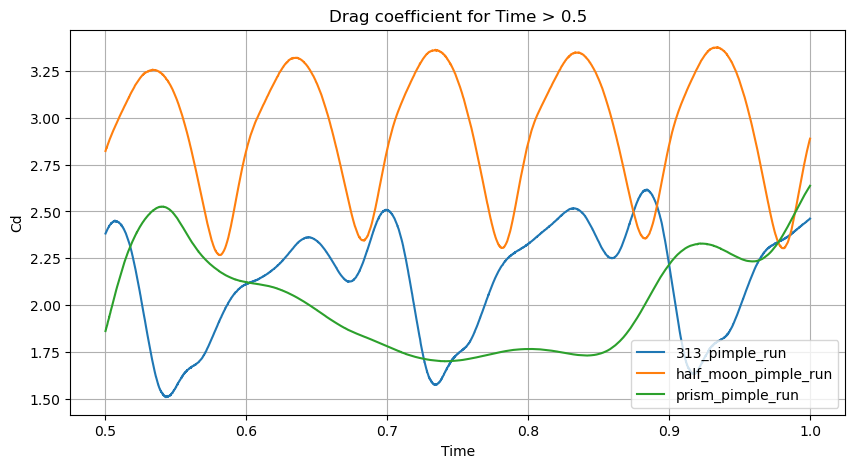

                 run  average_cd
      313_pimple_run    2.131732
half_moon_pimple_run    2.926085
    prism_pimple_run    2.031149


In [ ]:
from pathlib import Path

columns = [
    "Time", "Cd", "Cd(f)", "Cd(r)", "Cl", "Cl(f)", "Cl(r)",
    "CmPitch", "CmRoll", "CmYaw", "Cs", "Cs(f)", "Cs(r)"
]
time_threshold = 0.5
coefficient_files = sorted(
    Path("saved_runs").glob("*/postProcessing/forceCoeffs1/**/coefficient.dat")
)

results = []
plt.figure(figsize=(10, 5))

for coefficient_file in coefficient_files:
    df = pd.read_csv(
        coefficient_file,
        sep=r"\s+",
        comment="#",
        names=columns,
    )
    time_range = df[df["Time"] > time_threshold]
    time_interval = time_range["Time"].iloc[-1] - time_range["Time"].iloc[0]
    cd_integral = np.trapezoid(time_range["Cd"], time_range["Time"])
    average_cd = cd_integral / time_interval
    run_name = coefficient_file.relative_to("saved_runs").parts[0]

    results.append({"run": run_name, "average_cd": average_cd})
    plt.plot(time_range["Time"], time_range["Cd"], label=run_name)

plt.xlabel("Time")
plt.ylabel("Cd")
plt.title(f"Drag coefficient for Time > {time_threshold}")
plt.grid(True)
plt.legend()
plt.show()

average_results = pd.DataFrame(results)
print(average_results.to_string(index=False))


In [ ]:
coefficient_file_313 = Path(
    "saved_runs/313_pimple_run/postProcessing/forceCoeffs1/0/coefficient.dat"
)
df_313 = pd.read_csv(
    coefficient_file_313,
    sep=r"\s+",
    comment="#",
    names=columns,
)

plt.figure(figsize=(10, 5))
plt.plot(df_313["Time"], df_313["Cd"], label="Cd")
plt.plot(df_313["Time"], df_313["Cl"], label="Cl")
plt.xlabel("Time")
plt.ylabel("Coefficient")
plt.ylim(-4, 6)
plt.xlim(0, 1.2)
plt.grid(True)
plt.legend()
plt.show()